In [25]:
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [2]:
from sklearn.datasets import load_digits

In [3]:
digits = load_digits()

<Figure size 640x480 with 0 Axes>

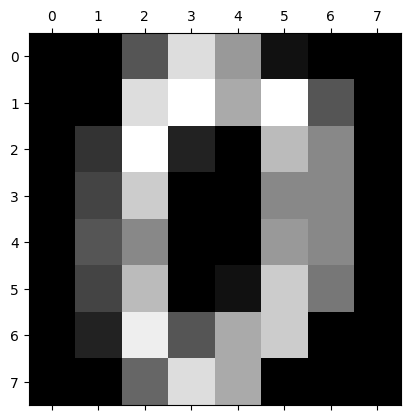

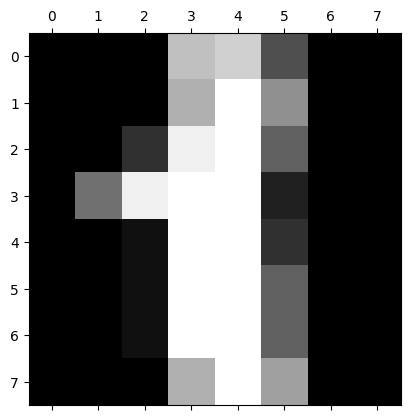

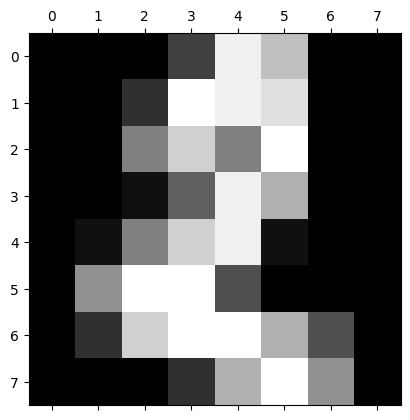

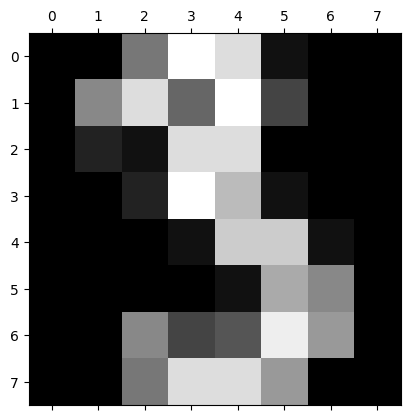

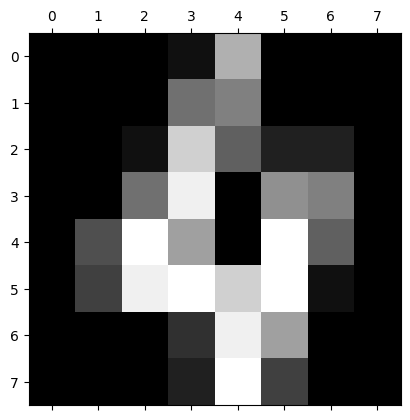

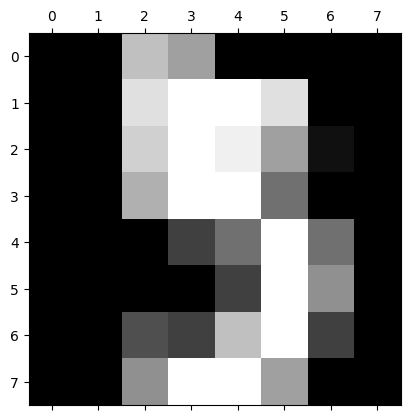

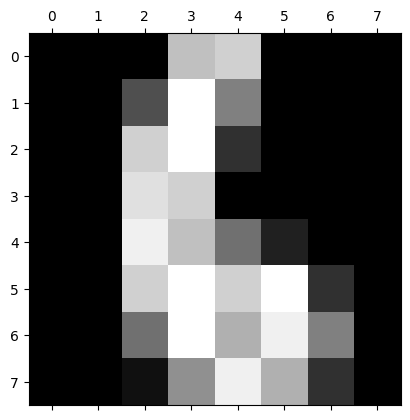

In [10]:
plt.gray()
for i in range(7): 
    plt.matshow(digits.images[i])

In [11]:
dir(digits)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

In [14]:
digits.data[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

In [17]:
digits.target

array([0, 1, 2, ..., 8, 9, 8])

In [19]:
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.2)
lg_reg = LogisticRegression()
lg_reg.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [20]:
lg_reg.score(X_test, y_test)

0.95

In [22]:
lg_reg.predict(digits.data[0:5])

array([0, 1, 2, 3, 4])

In [23]:
X_test

array([[ 0.,  0.,  3., ...,  0.,  0.,  0.],
       [ 0.,  0.,  8., ...,  0.,  0.,  0.],
       [ 0.,  0.,  2., ...,  8.,  0.,  0.],
       ...,
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0.,  8., ...,  0.,  0.,  0.],
       [ 0.,  0.,  2., ...,  0.,  0.,  0.]])

In [24]:
pred = lg_reg.predict(X_test)

In [26]:
conf_matrix = confusion_matrix(y_test, pred)

In [27]:
conf_matrix

array([[31,  0,  0,  0,  0,  4,  0,  0,  0,  0],
       [ 0, 35,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0, 32,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 30,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 26,  0,  0,  0,  1,  2],
       [ 0,  0,  0,  0,  0, 38,  0,  1,  0,  4],
       [ 0,  1,  0,  0,  0,  1, 36,  0,  0,  0],
       [ 0,  0,  0,  0,  1,  0,  0, 39,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 33,  0],
       [ 0,  0,  0,  2,  0,  0,  0,  0,  1, 42]])

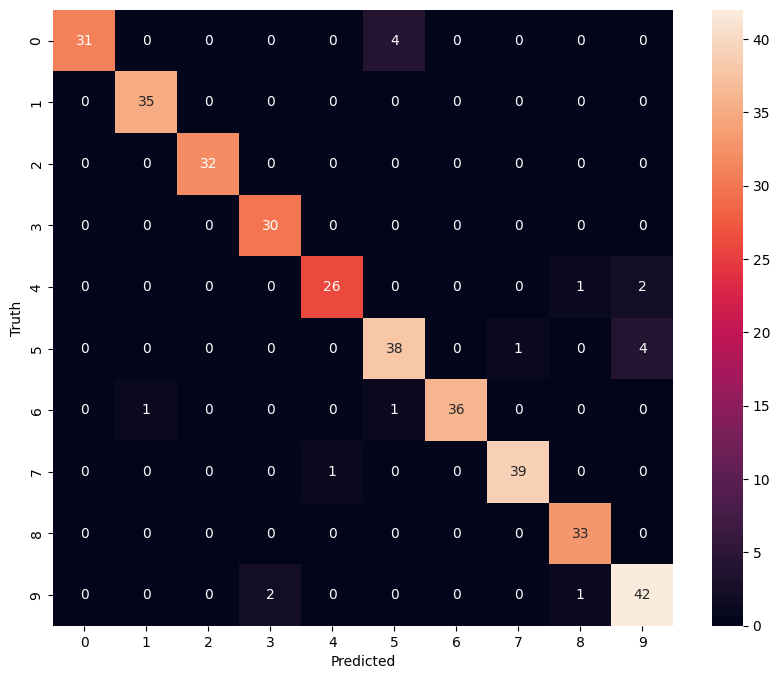

In [28]:
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True) 
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()